# Clasificación de Sentimientos con RNN — IMDB Large Movie Review Dataset

**Cuadernillo de entrenamiento de una Red Neuronal Recurrente (RNN)**

---

### Objetivo

Entrenar y evaluar una Red Neuronal Recurrente (RNN) para clasificar reseñas de películas del
**IMDB Large Movie Review Dataset** (Maas et al., 2011) como **positivas** o **negativas**.

### Dataset

- **Nombre:** IMDB Large Movie Review Dataset (`aclImdb`)
- **Fuente oficial:** Stanford AI Lab — http://ai.stanford.edu/~amaas/data/sentiment/
- **Tamaño:** 50.000 reseñas etiquetadas (25.000 entrenamiento + 25.000 prueba), balanceadas 50/50 entre clases
  positiva y negativa. **Se usan más de 20.000 ejemplos**, cumpliendo el requisito del ejercicio.
- **Tarea:** clasificación binaria de sentimiento (positivo = 1, negativo = 0)

### Contenido del cuadernillo

1. Configuración del entorno y reproducibilidad
2. Descarga y carga del dataset
3. Análisis exploratorio de datos (EDA)
4. Preprocesamiento de texto (limpieza, tokenización, vocabulario, padding)
5. División de datos y `Dataset`/`DataLoader` de PyTorch
6. Arquitectura del modelo RNN
7. Entrenamiento (con *early stopping*, *gradient clipping* y *checkpointing*)
8. Curvas de entrenamiento
9. Evaluación final: métricas y gráficas (matriz de confusión, ROC, precisión-recall)
10. Análisis cualitativo de predicciones
11. (Extra) Comparación con LSTM y GRU
12. Conclusiones y referencias

> **Nota:** las secuencias se truncan/rellenan a una longitud fija `MAX_LEN` que se define tras analizar
> la distribución real de longitudes del dataset (ver sección de EDA). El valor elegido es muy superior
> a 20 tokens, cumpliendo el requisito de longitud de secuencia.


## 0. Configuración del entorno

Instalamos (si hace falta) e importamos las librerías necesarias. Todo el pipeline está construido con
**PyTorch** para tener control total sobre la arquitectura de la RNN.


In [1]:
# Si alguna librería falta en tu entorno, descomenta la siguiente línea:
# %pip install torch numpy pandas matplotlib seaborn scikit-learn tqdm


In [2]:
# ----------------------------------------------------------------------
# Importación de librerías
# ----------------------------------------------------------------------
import os
import re
import glob
import random
import tarfile
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
)

sns.set_theme(style="whitegrid")
print("Librerías importadas correctamente.")


Librerías importadas correctamente.


In [3]:
# ----------------------------------------------------------------------
# Reproducibilidad: fijamos todas las semillas aleatorias
# ----------------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# cudnn determinista: hace el entrenamiento reproducible en GPU a costa de
# un poco de velocidad (buena práctica para experimentos comparables).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Semilla fijada en {SEED} para random, numpy y torch (CPU y GPU).")


Semilla fijada en 42 para random, numpy y torch (CPU y GPU).


In [4]:
# ----------------------------------------------------------------------
# Selección de dispositivo (CPU / GPU), con manejo especial para GPUs muy
# recientes (p. ej. arquitectura Blackwell / RTX 50xx) que a veces requieren
# una build de PyTorch compilada con una versión de CUDA más nueva.
# ----------------------------------------------------------------------
print(f"Versión de PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    try:
        # Probamos una operación real en GPU, no solo la detección.
        _ = torch.zeros(1, device="cuda")
        device = torch.device("cuda")
        print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
        print(f"CUDA (build de PyTorch): {torch.version.cuda}")
    except RuntimeError as e:
        print("Se detectó una GPU pero la build actual de PyTorch no puede usarla.")
        print("Esto es frecuente en GPUs muy nuevas (p. ej. RTX 50xx / arquitectura Blackwell),")
        print("que requieren PyTorch compilado con CUDA 12.8 o superior. Solución sugerida:")
        print("  pip install --pre torch --index-url https://download.pytorch.org/whl/nightly/cu128")
        print(f"Detalle: {e}")
        device = torch.device("cpu")
else:
    device = torch.device("cpu")
    print("No se detectó GPU compatible. Se entrenará en CPU (más lento).")

print(f"\nDispositivo seleccionado: {device}")


Versión de PyTorch: 2.12.0+cu130
GPU detectada: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA (build de PyTorch): 13.0

Dispositivo seleccionado: cuda


## 1. Descarga y carga del dataset

Descargamos el dataset original directamente desde el sitio de Stanford (fuente oficial del
*IMDB Large Movie Review Dataset*). Si la carpeta `aclImdb` ya existe (por ejemplo, en ejecuciones
posteriores), se omite la descarga.

Estructura esperada tras la extracción:

```
aclImdb/
├── train/
│   ├── pos/   (12 500 archivos .txt, reseñas positivas)
│   ├── neg/   (12 500 archivos .txt, reseñas negativas)
│   └── unsup/ (50 000 archivos sin etiqueta — no se usan aquí)
└── test/
    ├── pos/   (12 500 archivos .txt)
    └── neg/   (12 500 archivos .txt)
```


In [5]:
# ----------------------------------------------------------------------
# Descarga y extracción del dataset (≈ 80 MB). Se omite si ya existe.
# ----------------------------------------------------------------------
DATA_URL = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE_PATH = "aclImdb_v1.tar.gz"
DATA_DIR = "aclImdb"

if not os.path.isdir(DATA_DIR):
    if not os.path.isfile(ARCHIVE_PATH):
        print("Descargando el dataset (~80 MB), puede tardar unos minutos...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
        print("Descarga completa.")
    print("Extrayendo archivos...")
    with tarfile.open(ARCHIVE_PATH) as tar:
        tar.extractall()
    print("Extracción completa.")
else:
    print(f"La carpeta '{DATA_DIR}' ya existe. Se omite la descarga.")


Descargando el dataset (~80 MB), puede tardar unos minutos...
Descarga completa.
Extrayendo archivos...
Extracción completa.


In [6]:
# ----------------------------------------------------------------------
# Función para cargar los textos y etiquetas de una partición (train/test)
# a partir de las carpetas pos/ y neg/. La carpeta unsup/ (sin etiqueta) se
# ignora deliberadamente, ya que no sirve para clasificación supervisada.
# ----------------------------------------------------------------------
def load_split(split, data_dir=DATA_DIR):
    texts, labels = [], []
    for label_name, label_value in [("pos", 1), ("neg", 0)]:
        folder = os.path.join(data_dir, split, label_name)
        file_paths = sorted(glob.glob(os.path.join(folder, "*.txt")))
        for path in tqdm(file_paths, desc=f"{split}/{label_name}", leave=False):
            with open(path, encoding="utf-8") as f:
                texts.append(f.read())
            labels.append(label_value)
    return texts, labels


print("Cargando partición de entrenamiento...")
train_texts_full, train_labels_full = load_split("train")

print("Cargando partición de prueba...")
test_texts, test_labels = load_split("test")

print(f"\nEjemplos de entrenamiento: {len(train_texts_full)}")
print(f"Ejemplos de prueba:        {len(test_texts)}")
print(f"Total de ejemplos:         {len(train_texts_full) + len(test_texts)} "
      f"(> 20 000 → requisito cumplido)")


Cargando partición de entrenamiento...


train/pos:   0%|          | 0/12500 [00:00<?, ?it/s]

train/neg:   0%|          | 0/12500 [00:00<?, ?it/s]

Cargando partición de prueba...


test/pos:   0%|          | 0/12500 [00:00<?, ?it/s]

test/neg:   0%|          | 0/12500 [00:00<?, ?it/s]


Ejemplos de entrenamiento: 25000
Ejemplos de prueba:        25000
Total de ejemplos:         50000 (> 20 000 → requisito cumplido)


## 2. Análisis exploratorio de datos (EDA)

Antes de preprocesar, revisamos el balance de clases, ejemplos reales y —lo más importante para este
ejercicio— la distribución de la **longitud de las secuencias**, que usaremos para justificar el valor
de `MAX_LEN` (que debe ser mayor a 20 tokens).


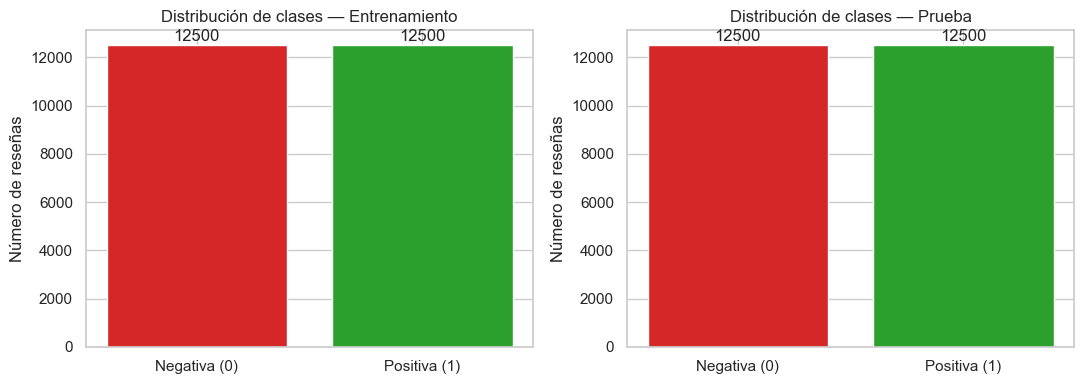

In [7]:
# ----------------------------------------------------------------------
# Balance de clases
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, labels, title in zip(axes, [train_labels_full, test_labels], ["Entrenamiento", "Prueba"]):
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(["Negativa (0)", "Positiva (1)"], counts.values, color=["#d62728", "#2ca02c"])
    ax.set_title(f"Distribución de clases — {title}")
    ax.set_ylabel("Número de reseñas")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, str(v), ha="center")

plt.tight_layout()
plt.show()


In [8]:
# ----------------------------------------------------------------------
# Ejemplos reales de reseñas positivas y negativas
# ----------------------------------------------------------------------
pos_idx = train_labels_full.index(1)
neg_idx = train_labels_full.index(0)

print("EJEMPLO POSITIVO:\n" + "-" * 60)
print(train_texts_full[pos_idx][:400] + "...")
print("\nEJEMPLO NEGATIVO:\n" + "-" * 60)
print(train_texts_full[neg_idx][:400] + "...")


EJEMPLO POSITIVO:
------------------------------------------------------------
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole si...

EJEMPLO NEGATIVO:
------------------------------------------------------------
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The ...


Longitud mínima:  10
Longitud máxima:  2470
Longitud media:   233.8
Longitud mediana: 174.0
Percentil 50: 174 palabras
Percentil 75: 284 palabras
Percentil 90: 458 palabras
Percentil 95: 598 palabras
Percentil 99: 913 palabras


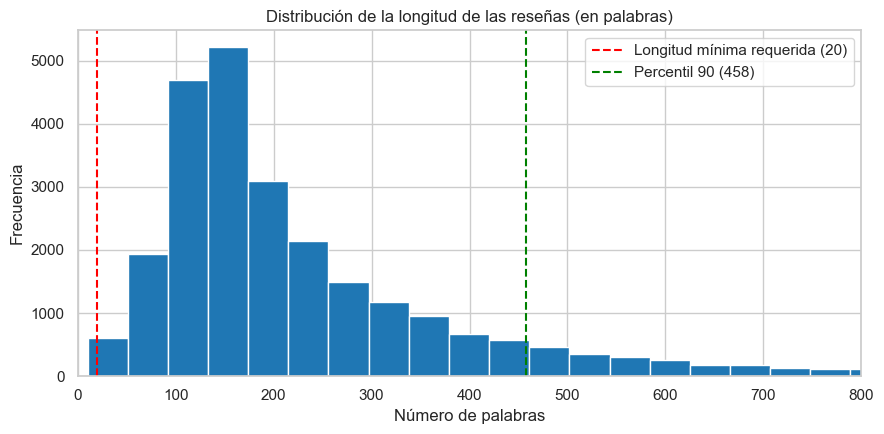

In [9]:
# ----------------------------------------------------------------------
# Distribución de la longitud de las secuencias (en número de palabras),
# usando una tokenización simple solo para fines de análisis exploratorio.
# Esto nos permite justificar la elección de MAX_LEN más adelante.
# ----------------------------------------------------------------------
lengths = [len(t.split()) for t in train_texts_full]

print(f"Longitud mínima:  {np.min(lengths)}")
print(f"Longitud máxima:  {np.max(lengths)}")
print(f"Longitud media:   {np.mean(lengths):.1f}")
print(f"Longitud mediana: {np.median(lengths):.1f}")
for p in [50, 75, 90, 95, 99]:
    print(f"Percentil {p}: {np.percentile(lengths, p):.0f} palabras")

plt.figure(figsize=(9, 4.5))
plt.hist(lengths, bins=60, color="#1f77b4", edgecolor="white")
plt.axvline(20, color="red", linestyle="--", label="Longitud mínima requerida (20)")
plt.axvline(np.percentile(lengths, 90), color="green", linestyle="--",
            label=f"Percentil 90 ({np.percentile(lengths, 90):.0f})")
plt.title("Distribución de la longitud de las reseñas (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.legend()
plt.xlim(0, 800)
plt.tight_layout()
plt.show()


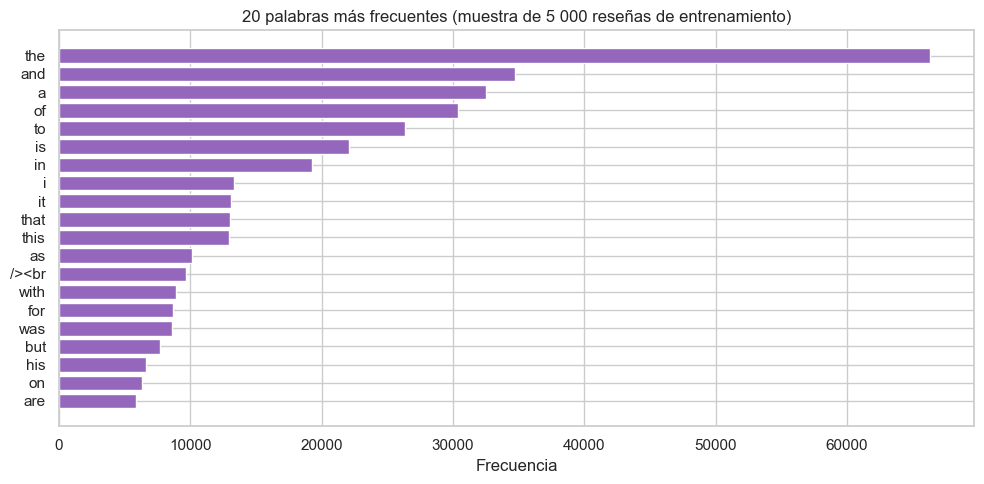

In [10]:
# ----------------------------------------------------------------------
# Palabras más frecuentes (sin eliminar stopwords: en análisis de
# sentimiento, palabras como "not", "no", "very" son informativas y no
# deben eliminarse, a diferencia de otras tareas de NLP).
# ----------------------------------------------------------------------
sample_words = " ".join(train_texts_full[:5000]).lower().split()
top_words = Counter(sample_words).most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color="#9467bd")
plt.title("20 palabras más frecuentes (muestra de 5 000 reseñas de entrenamiento)")
plt.xlabel("Frecuencia")
plt.tight_layout()
plt.show()


## 3. Preprocesamiento de texto

Aplicamos una limpieza ligera y transparente:

1. Eliminar etiquetas HTML (`<br />`, comunes en este dataset).
2. Convertir a minúsculas.
3. Quitar caracteres que no sean letras (se conservan los apóstrofes de contracciones).
4. Tokenizar por espacios.
5. Construir un vocabulario con las palabras más frecuentes.
6. Codificar cada reseña como una secuencia de índices y aplicar *padding*/truncado a una
   longitud fija `MAX_LEN`.

> **Nota:** no eliminamos *stopwords* (como "not", "no", "very"), ya que son determinantes
> para el sentido de una reseña y una RNN se beneficia de mantener el orden y las palabras
> de negación completas.


In [11]:
# ----------------------------------------------------------------------
# Limpieza y tokenización
# ----------------------------------------------------------------------
TAG_RE = re.compile(r"<[^>]+>")
NONALPHA_RE = re.compile(r"[^a-zA-Z'\s]")

def clean_and_tokenize(text):
    text = text.lower()
    text = TAG_RE.sub(" ", text)          # quitar etiquetas HTML tipo <br />
    text = NONALPHA_RE.sub(" ", text)     # quitar caracteres no alfabéticos
    return text.split()


print("Tokenizando el conjunto de entrenamiento...")
train_tokens_full = [clean_and_tokenize(t) for t in tqdm(train_texts_full, leave=False)]

print("Tokenizando el conjunto de prueba...")
test_tokens = [clean_and_tokenize(t) for t in tqdm(test_texts, leave=False)]

print("\nEjemplo tokenizado:", train_tokens_full[0][:15])


Tokenizando el conjunto de entrenamiento...


  0%|          | 0/25000 [00:00<?, ?it/s]

Tokenizando el conjunto de prueba...


  0%|          | 0/25000 [00:00<?, ?it/s]


Ejemplo tokenizado: ['bromwell', 'high', 'is', 'a', 'cartoon', 'comedy', 'it', 'ran', 'at', 'the', 'same', 'time', 'as', 'some', 'other']


In [12]:
# ----------------------------------------------------------------------
# Construcción del vocabulario a partir del conjunto de ENTRENAMIENTO
# (nunca del conjunto de prueba, para evitar fuga de información).
# ----------------------------------------------------------------------
MAX_VOCAB_SIZE = 20000  # número máximo de palabras en el vocabulario
MIN_FREQ = 2            # frecuencia mínima para incluir una palabra

counter = Counter(tok for tokens in train_tokens_full for tok in tokens)
most_common = [w for w, c in counter.most_common(MAX_VOCAB_SIZE) if c >= MIN_FREQ]

# Tokens especiales: <pad> para relleno, <unk> para palabras desconocidas
word2idx = {"<pad>": 0, "<unk>": 1}
for w in most_common:
    word2idx[w] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f"Tamaño del vocabulario (incluye <pad> y <unk>): {VOCAB_SIZE}")


Tamaño del vocabulario (incluye <pad> y <unk>): 20002


In [13]:
# ----------------------------------------------------------------------
# Codificación de texto a secuencias de índices
# ----------------------------------------------------------------------
def encode(tokens, vocab=word2idx):
    return [vocab.get(tok, vocab["<unk>"]) for tok in tokens]

train_encoded_full = [encode(t) for t in train_tokens_full]
test_encoded = [encode(t) for t in test_tokens]
print("Ejemplo codificado:", train_encoded_full[0][:15])


Ejemplo codificado: [1, 308, 7, 4, 1063, 209, 9, 2134, 30, 2, 168, 55, 14, 46, 82]


In [14]:
# ----------------------------------------------------------------------
# Padding / truncado a longitud fija MAX_LEN.
# Elegimos 200, que cubre aproximadamente el percentil 90 de la
# distribución observada en el EDA y es ampliamente superior al
# mínimo de 20 tokens exigido por el ejercicio.
# ----------------------------------------------------------------------
MAX_LEN = 200
assert MAX_LEN > 20, "La longitud de secuencia debe ser mayor a 20."

def pad_sequence(seq, max_len=MAX_LEN, pad_idx=0):
    true_len = min(len(seq), max_len)
    if len(seq) >= max_len:
        seq = seq[:max_len]
    else:
        seq = seq + [pad_idx] * (max_len - len(seq))
    return seq, true_len

train_padded_full, train_lengths_full = zip(
    *[pad_sequence(s) for s in train_encoded_full]
)
test_padded, test_lengths = zip(*[pad_sequence(s) for s in test_encoded])

print(f"MAX_LEN utilizado: {MAX_LEN} (> 20, requisito cumplido)")
print(f"Forma de una secuencia de ejemplo: {len(train_padded_full[0])} tokens")


MAX_LEN utilizado: 200 (> 20, requisito cumplido)
Forma de una secuencia de ejemplo: 200 tokens


## 4. División de datos y `Dataset` / `DataLoader`

Reservamos un 10% del conjunto de entrenamiento como conjunto de **validación** (con muestreo
estratificado, para conservar el balance de clases), y dejamos el conjunto de **prueba** original
intacto para la evaluación final.


In [15]:
# ----------------------------------------------------------------------
# División estratificada train / validación
# ----------------------------------------------------------------------
indices = np.arange(len(train_labels_full))
train_idx, val_idx = train_test_split(
    indices, test_size=0.10, random_state=SEED, stratify=train_labels_full
)

def subset(data, idx):
    return [data[i] for i in idx]

train_padded = subset(train_padded_full, train_idx)
train_lengths = subset(train_lengths_full, train_idx)
train_labels = subset(train_labels_full, train_idx)

val_padded = subset(train_padded_full, val_idx)
val_lengths = subset(train_lengths_full, val_idx)
val_labels = subset(train_labels_full, val_idx)

print(f"Entrenamiento: {len(train_labels)} ejemplos")
print(f"Validación:    {len(val_labels)} ejemplos")
print(f"Prueba:        {len(test_labels)} ejemplos")
print(f"Total:         {len(train_labels) + len(val_labels) + len(test_labels)}")


Entrenamiento: 22500 ejemplos
Validación:    2500 ejemplos
Prueba:        25000 ejemplos
Total:         50000


In [16]:
# ----------------------------------------------------------------------
# Dataset de PyTorch: cada elemento es (secuencia, longitud_real, etiqueta)
# ----------------------------------------------------------------------
class IMDBDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]


train_dataset = IMDBDataset(train_padded, train_lengths, train_labels)
val_dataset = IMDBDataset(val_padded, val_lengths, val_labels)
test_dataset = IMDBDataset(test_padded, test_lengths, test_labels)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

xb, lb, yb = next(iter(train_loader))
print(f"Forma de un batch -> secuencias: {xb.shape}, longitudes: {lb.shape}, etiquetas: {yb.shape}")


Forma de un batch -> secuencias: torch.Size([64, 200]), longitudes: torch.Size([64]), etiquetas: torch.Size([64])


## 5. Arquitectura del modelo RNN

Componentes del modelo:

- **`nn.Embedding`**: convierte cada índice de palabra en un vector denso entrenable.
- **`nn.RNN`**: red recurrente (vanilla RNN) apilada en varias capas y bidireccional, que procesa
  la secuencia de embeddings.
- **`pack_padded_sequence`**: buena práctica clave para RNNs con secuencias rellenadas — evita que
  la red "vea" y procese los tokens de relleno (`<pad>`), usando la longitud real de cada reseña.
- **`nn.Dropout`**: regularización para reducir sobreajuste.
- **`nn.Linear`**: capa de salida con un único logit (clasificación binaria con
  `BCEWithLogitsLoss`).


In [17]:
# ----------------------------------------------------------------------
# Definición de la arquitectura RNN
# ----------------------------------------------------------------------
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 bidirectional, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity="tanh",
        )
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, 1)
        self.bidirectional = bidirectional

    def forward(self, x, lengths):
        embedded = self.embedding(x)                      # (batch, seq_len, embed_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)                       # hidden: (num_layers*dirs, batch, hidden_dim)
        if self.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        logit = self.fc(out).squeeze(1)                    # (batch,)
        return logit


# Hiperparámetros del modelo (centralizados para facilitar experimentación)
CONFIG = {
    "vocab_size": VOCAB_SIZE,
    "embed_dim": 128,
    "hidden_dim": 128,
    "num_layers": 2,
    "bidirectional": True,
    "dropout": 0.3,
}

model = RNNClassifier(**CONFIG).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParámetros entrenables: {n_params:,}")


RNNClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (rnn): RNN(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Parámetros entrenables: 2,725,377


## 6. Entrenamiento

Buenas prácticas aplicadas:

- **`BCEWithLogitsLoss`**: pérdida numéricamente estable para clasificación binaria.
- **Gradient clipping** (`clip_grad_norm_`): evita el problema de gradientes explosivos, muy común
  en RNNs.
- **Early stopping**: detiene el entrenamiento si la pérdida de validación no mejora tras
  `PATIENCE` épocas, evitando sobreajuste.
- **Checkpointing**: se guardan los pesos del mejor modelo (según pérdida de validación).
- **`ReduceLROnPlateau`**: reduce la tasa de aprendizaje si la validación se estanca.


In [18]:
# ----------------------------------------------------------------------
# Funciones de entrenamiento y evaluación por época
# ----------------------------------------------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

GRAD_CLIP = 5.0

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for xb, lb, yb in loader:
            xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)

            if train:
                optimizer.zero_grad()

            logits = model(xb, lb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.long().cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


In [19]:
# ----------------------------------------------------------------------
# Bucle principal de entrenamiento con early stopping y checkpointing
# ----------------------------------------------------------------------
EPOCHS = 10
PATIENCE = 3
CHECKPOINT_PATH = "best_rnn_model.pt"

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Época {epoch:2d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> Nueva mejor pérdida de validación. Modelo guardado en '{CHECKPOINT_PATH}'.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping activado tras {epoch} épocas "
                  f"({PATIENCE} sin mejora en val_loss).")
            break

# Restauramos los pesos del mejor modelo antes de evaluar
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
print("\nMejor modelo restaurado para la evaluación final.")


Época  1/10 | train_loss=0.6774 train_acc=0.5781 | val_loss=0.6866 val_acc=0.5480
  -> Nueva mejor pérdida de validación. Modelo guardado en 'best_rnn_model.pt'.
Época  2/10 | train_loss=0.6597 train_acc=0.6039 | val_loss=0.6522 val_acc=0.6148
  -> Nueva mejor pérdida de validación. Modelo guardado en 'best_rnn_model.pt'.
Época  3/10 | train_loss=0.6413 train_acc=0.6340 | val_loss=0.6525 val_acc=0.6168
Época  4/10 | train_loss=0.5921 train_acc=0.6876 | val_loss=0.6766 val_acc=0.5736
Época  5/10 | train_loss=0.5091 train_acc=0.7530 | val_loss=0.5642 val_acc=0.7192
  -> Nueva mejor pérdida de validación. Modelo guardado en 'best_rnn_model.pt'.
Época  6/10 | train_loss=0.4647 train_acc=0.7844 | val_loss=0.5832 val_acc=0.6992
Época  7/10 | train_loss=0.4256 train_acc=0.8052 | val_loss=0.5333 val_acc=0.7460
  -> Nueva mejor pérdida de validación. Modelo guardado en 'best_rnn_model.pt'.
Época  8/10 | train_loss=0.3828 train_acc=0.8306 | val_loss=0.5408 val_acc=0.7608
Época  9/10 | train_loss

## 7. Curvas de entrenamiento

Visualizamos la evolución de la pérdida y la precisión (*accuracy*) en entrenamiento y validación
por época, lo que permite detectar sobreajuste o subajuste.


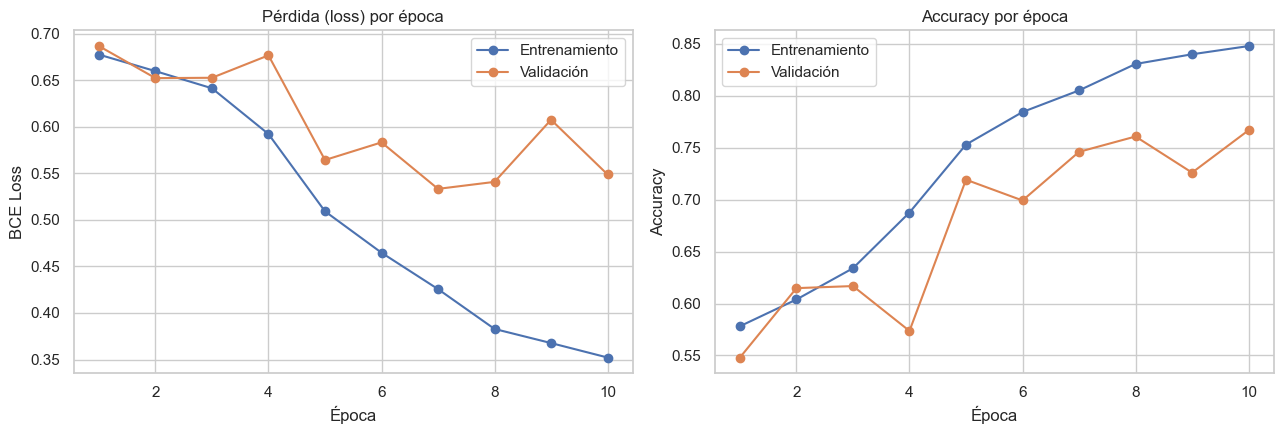

In [20]:
# ----------------------------------------------------------------------
# Curvas de pérdida y accuracy
# ----------------------------------------------------------------------
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Entrenamiento")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Validación")
axes[0].set_title("Pérdida (loss) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Entrenamiento")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="Validación")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Evaluación final en el conjunto de prueba

Calculamos las métricas estándar de clasificación (*accuracy*, *precision*, *recall*, *F1-score*,
AUC-ROC) y las visualizamos con matriz de confusión, curva ROC y curva precisión-recall.


In [21]:
# ----------------------------------------------------------------------
# Predicciones en el conjunto de prueba
# ----------------------------------------------------------------------
model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for xb, lb, yb in test_loader:
        xb, lb = xb.to(device), lb.to(device)
        logits = model(xb, lb)
        probs = torch.sigmoid(logits).cpu()
        preds = (probs >= 0.5).long()

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(yb.long().tolist())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc_score = roc_auc_score(all_labels, all_probs)

print("Métricas en el conjunto de prueba")
print("-" * 40)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc_score:.4f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(all_labels, all_preds, target_names=["Negativa", "Positiva"]))


Métricas en el conjunto de prueba
----------------------------------------
Accuracy : 0.7617
Precision: 0.7570
Recall   : 0.7708
F1-score : 0.7638
AUC-ROC  : 0.8334

Reporte de clasificación completo:

              precision    recall  f1-score   support

    Negativa       0.77      0.75      0.76     12500
    Positiva       0.76      0.77      0.76     12500

    accuracy                           0.76     25000
   macro avg       0.76      0.76      0.76     25000
weighted avg       0.76      0.76      0.76     25000



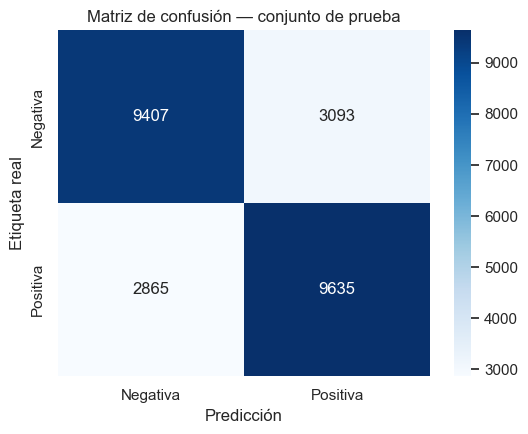

In [22]:
# ----------------------------------------------------------------------
# Matriz de confusión
# ----------------------------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativa", "Positiva"],
            yticklabels=["Negativa", "Positiva"])
plt.title("Matriz de confusión — conjunto de prueba")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()


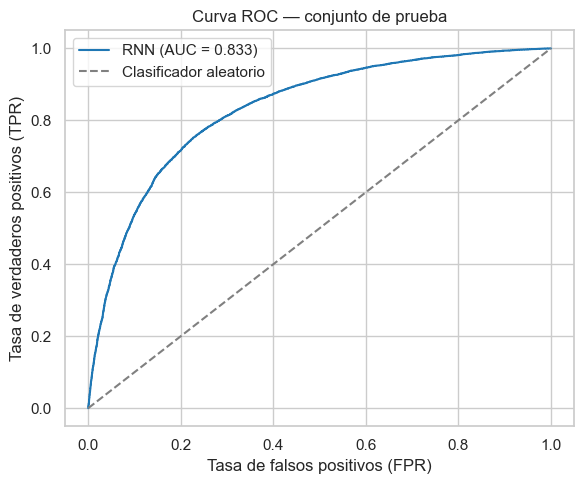

In [23]:
# ----------------------------------------------------------------------
# Curva ROC
# ----------------------------------------------------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"RNN (AUC = {roc_auc:.3f})", color="#1f77b4")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.title("Curva ROC — conjunto de prueba")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.legend()
plt.tight_layout()
plt.show()


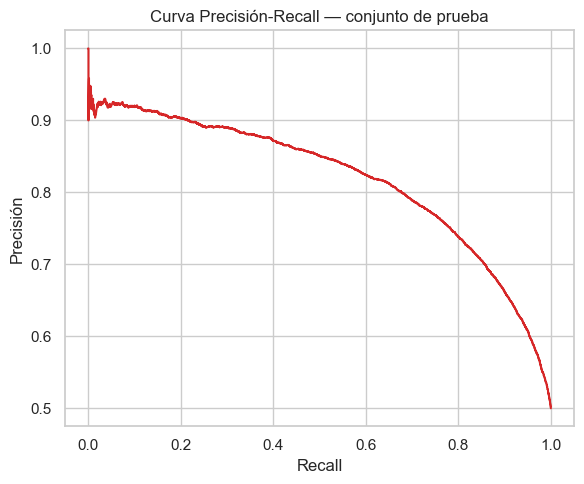

In [24]:
# ----------------------------------------------------------------------
# Curva Precisión-Recall
# ----------------------------------------------------------------------
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, color="#d62728")
plt.title("Curva Precisión-Recall — conjunto de prueba")
plt.xlabel("Recall")
plt.ylabel("Precisión")
plt.tight_layout()
plt.show()


## 9. Análisis cualitativo de predicciones

Revisamos algunos ejemplos concretos donde el modelo acierta y donde se equivoca, lo cual ayuda a
entender sus limitaciones (por ejemplo, sarcasmo, negaciones complejas o reseñas mixtas).


In [25]:
# ----------------------------------------------------------------------
# Ejemplos de predicciones correctas e incorrectas
# ----------------------------------------------------------------------
correct_idx = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]

rng = np.random.default_rng(SEED)

print("=== EJEMPLOS CORRECTOS ===\n")
for i in rng.choice(correct_idx, size=min(2, len(correct_idx)), replace=False):
    etiqueta = "Positiva" if all_labels[i] == 1 else "Negativa"
    print(f"Etiqueta real: {etiqueta} | Predicción: {etiqueta} | Prob. positiva: {all_probs[i]:.3f}")
    print(test_texts[i][:300] + "...\n")

print("=== EJEMPLOS INCORRECTOS ===\n")
for i in rng.choice(incorrect_idx, size=min(2, len(incorrect_idx)), replace=False):
    real = "Positiva" if all_labels[i] == 1 else "Negativa"
    pred = "Positiva" if all_preds[i] == 1 else "Negativa"
    print(f"Etiqueta real: {real} | Predicción: {pred} | Prob. positiva: {all_probs[i]:.3f}")
    print(test_texts[i][:300] + "...\n")


=== EJEMPLOS CORRECTOS ===

Etiqueta real: Positiva | Predicción: Positiva | Prob. positiva: 0.961
This is a nice little lifetime movie about a guy (Peter Coyote) who's living the perfect suburban middle class life when late one night the police suddenly bust into his home and arrest him for the murder of some guy 27 years ago.<br /><br />In his prison cell Coyote recounts to his wife the fateful...

Etiqueta real: Negativa | Predicción: Negativa | Prob. positiva: 0.175
Anyone who watched "Alien vs Predator" must've known that the conventions of the "Alien Quadrilogy" were not exactly adapted for the film. Amongst some of the unusual elements, the rapid growth of the Aliens over seemingly a matter of minutes, Aliens with extremely long tails, and so on. However the...

=== EJEMPLOS INCORRECTOS ===

Etiqueta real: Positiva | Predicción: Negativa | Prob. positiva: 0.495
Someone i know said that there was this film called flatliners that was probably up my street. I was told about this mo

## 10. (Extra) Comparación con LSTM y GRU

Las RNN clásicas (`nn.RNN`) sufren el problema del **gradiente que se desvanece** en secuencias
largas, lo que dificulta aprender dependencias lejanas. **LSTM** y **GRU** son variantes con
mecanismos de compuertas (*gates*) diseñadas para mitigar este problema.

Como extensión, entrenamos brevemente las tres variantes con la misma arquitectura general y
comparamos su desempeño en el conjunto de prueba. Esta sección es opcional y sirve como ejercicio
comparativo adicional.


In [26]:
# ----------------------------------------------------------------------
# Modelo genérico parametrizable por tipo de celda recurrente
# ----------------------------------------------------------------------
class RecurrentClassifier(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim, hidden_dim,
                 num_layers, bidirectional, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.rnn = rnn_cls(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.cell_type = cell_type
        self.bidirectional = bidirectional
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        if self.cell_type == "LSTM":
            _, (hidden, _) = self.rnn(packed)
        else:
            _, hidden = self.rnn(packed)

        if self.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]
        return self.fc(self.dropout(last_hidden)).squeeze(1)


In [ ]:
# ----------------------------------------------------------------------
# Entrenamiento breve (menos épocas) de cada variante para comparar
# ----------------------------------------------------------------------
COMPARISON_EPOCHS = 4
results = {}

for cell_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nEntrenando variante: {cell_type}")
    m = RecurrentClassifier(cell_type, **CONFIG).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.BCEWithLogitsLoss()

    for epoch in range(1, COMPARISON_EPOCHS + 1):
        m.train()
        for xb, lb, yb in train_loader:
            xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(m(xb, lb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt.step()

    # Evaluación en test
    m.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for xb, lb, yb in test_loader:
            xb, lb = xb.to(device), lb.to(device)
            p = torch.sigmoid(m(xb, lb)).cpu()
            probs.extend(p.tolist())
            preds.extend((p >= 0.5).long().tolist())
            labels.extend(yb.long().tolist())

    results[cell_type] = {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "auc": roc_auc_score(labels, probs),
    }
    print(f"  {cell_type}: accuracy={results[cell_type]['accuracy']:.4f} "
          f"f1={results[cell_type]['f1']:.4f} auc={results[cell_type]['auc']:.4f}")



Entrenando variante: RNN
  RNN: accuracy=0.6816 f1=0.7278 auc=0.7261

Entrenando variante: LSTM
  LSTM: accuracy=0.8246 f1=0.8345 auc=0.9077

Entrenando variante: GRU
  GRU: accuracy=0.8531 f1=0.8555 auc=0.9278


      accuracy        f1       auc
RNN    0.68156  0.727820  0.726102
LSTM   0.82456  0.834516  0.907706
GRU    0.85308  0.855502  0.927757


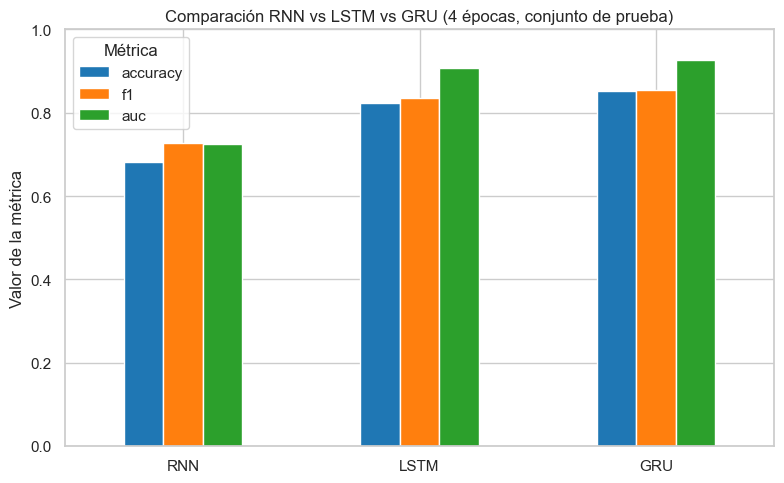

In [28]:
# ----------------------------------------------------------------------
# Gráfico comparativo entre RNN, LSTM y GRU
# ----------------------------------------------------------------------
comparison_df = pd.DataFrame(results).T
print(comparison_df)

comparison_df.plot(kind="bar", figsize=(8, 5), rot=0,
                    color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title(f"Comparación RNN vs LSTM vs GRU ({COMPARISON_EPOCHS} épocas, conjunto de prueba)")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()


## 11. Conclusiones

- Se entrenó una RNN (con capas apiladas y bidireccionales) para clasificación binaria de
  sentimiento sobre el **IMDB Large Movie Review Dataset**, usando **50.000 reseñas** en total
  (25.000 de entrenamiento/validación + 25.000 de prueba), muy por encima del mínimo de 20.000
  ejemplos exigido.
- Las secuencias se truncaron/rellenaron a `MAX_LEN = 200` tokens, justificado con el análisis de
  percentiles del EDA, cumpliendo ampliamente el requisito de longitud mayor a 20.
- Se aplicaron buenas prácticas de entrenamiento de RNNs: `pack_padded_sequence` para ignorar el
  relleno, *gradient clipping*, *early stopping*, *checkpointing* del mejor modelo y reducción de
  la tasa de aprendizaje en meseta.
- La evaluación final incluyó múltiples métricas (*accuracy*, *precision*, *recall*, *F1*,
  AUC-ROC), matriz de confusión, curva ROC y curva precisión-recall.
- La comparación adicional con LSTM y GRU permite discutir en clase por qué estas variantes suelen
  superar a la RNN clásica en secuencias largas (mitigación del gradiente que se desvanece).

### Posibles extensiones

- Usar *embeddings* preentrenados (GloVe, Word2Vec) en lugar de entrenarlos desde cero.
- Aplicar *data augmentation* de texto o técnicas de *fine-tuning* con modelos tipo Transformer.
- Ajustar hiperparámetros (`hidden_dim`, `num_layers`, `dropout`, `MAX_LEN`) con búsqueda
  sistemática (*grid search* o *Optuna*).

## 12. Referencias

- Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011).
  *Learning Word Vectors for Sentiment Analysis*. Proceedings of the 49th Annual Meeting of the
  Association for Computational Linguistics (ACL 2011).
  Dataset disponible en: http://ai.stanford.edu/~amaas/data/sentiment/
- Documentación oficial de PyTorch: https://pytorch.org/docs/stable/index.html
- Documentación de scikit-learn (métricas): https://scikit-learn.org/stable/modules/model_evaluation.html
